Basic Truss Analysis Using Direct Stiffness Method

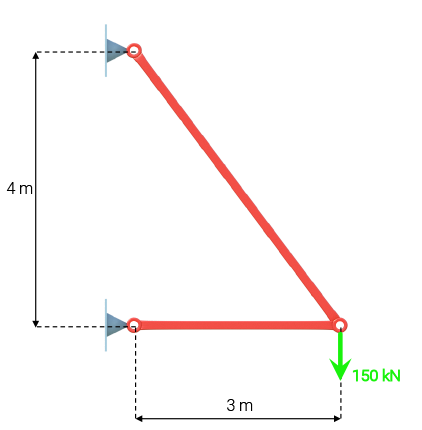 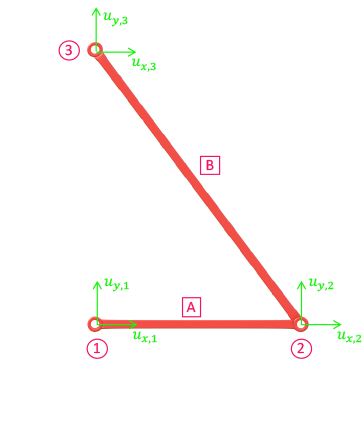

In [12]:
#Imports
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

#Constants
E= 200*10**9 ## N/m^2
A= 0.005      ## m^2
nDof= 6        ## Total degrees of freedom
restrainedDof= [1,2,5,6]



## Define a function to calculate member global stiffness matrix

In [13]:
def calculateKg(E,A,L,theta):
    c = math.cos(theta)
    s = math.sin(theta)

    K11=(E*A/L)*np.array([[c**2,c*s],
                            [c*s,s**2]])
    K12=(E*A/L)*np.array([[-c**2,-c*s],
                            [-c*s,-s**2]])
    K21=(E*A/L)*np.array([[-c**2,-c*s],
                            [-c*s,-s**2]])
    K22=(E*A/L)*np.array([[c**2,c*s],
                            [c*s,s**2]])
    return[K11,K12,K21,K22]

    

In [14]:
[K11_12,K12_12,K21_12,K22_12]=calculateKg(E,A,3,0)  ## Member A
[K11_23,K12_23,K21_23,K22_23]=calculateKg(E,A,5,2.2143)  ## Member B



## Primary Stiffness Matrix for Structure

In [15]:
k11= K11_12
k12= K12_12
k13= np.zeros([2,2])

k21= K21_12
k22= K22_12+ K11_23
k23= K12_23

k31= np.zeros([2,2])
k32= K21_23
k33= K22_23

r1=np.concatenate((k11,k12,k13),axis=1)
r2=np.concatenate((k21,k22,k23),axis=1)
r3=np.concatenate((k31,k32,k33),axis=1)
Kp=np.concatenate((r1,r2,r3),axis=0)
print(np.round(Kp,3))

[[ 3.33333333e+08  0.00000000e+00 -3.33333333e+08 -0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.33333333e+08 -0.00000000e+00  4.05333826e+08 -9.60001436e+07
  -7.20004924e+07  9.60001436e+07]
 [-0.00000000e+00 -0.00000000e+00 -9.60001436e+07  1.27999508e+08
   9.60001436e+07 -1.27999508e+08]
 [ 0.00000000e+00  0.00000000e+00 -7.20004924e+07  9.60001436e+07
   7.20004924e+07 -9.60001436e+07]
 [ 0.00000000e+00  0.00000000e+00  9.60001436e+07 -1.27999508e+08
  -9.60001436e+07  1.27999508e+08]]


## Extract the Structure Stiffness Matrix

In [18]:
restrainedIndex= [x-1 for x in restrainedDof]  ## index for each restrained Dof

# Reduce to structure stiffness matrix by deleting the rows and columns for restrained Dof
Ks=np.delete(Kp,restrainedIndex,0)         # Delete rows
Ks=np.delete(Ks,restrainedIndex,1)         # Delete Columns
Ks=np.matrix(Ks)




In [19]:

U2= Ks.I*np.array([[0],
                   [-150000]])
U_x2=U2[0,0]
U_y2=U2[1,0]
print("The Horizontal Displacement at node 2 is {one}m (to the left)".format(one=round(U_x2,6)))
print(f"The Vertical Displacement at node 2 is {U_y2:.6f}m (downwards)")


The Horizontal Displacement at node 2 is -0.000338m (to the left)
The Vertical Displacement at node 2 is -0.001425m (downwards)


## Reaction forces

In [20]:
# Construct a global displacement vector
UG=np.array([[0,0,U_x2,U_y2,0,0]])
FG= np.matmul(Kp,UG.T)

print(np.round(FG,3))

[[ 112500.601]
 [      0.   ]
 [     -0.   ]
 [-150000.   ]
 [-112500.601]
 [ 150000.   ]]


## Solve for Member Forces

In [23]:
# Write a function that calculates member forces based on nodal displacements
def calculateForce(E,A,L,theta,Ua,Ub):
    
    #Transformation Matrix
    c= math.cos(theta)
    s=math.sin(theta)
    T=np.array([[c,s,0,0],
                [0,0,c,s]])
    disp=np.array([[Ua[0],Ua[1],Ub[0],Ub[1]]]).T               ## Transpose for making it Column Vector
    disp_local= np.matmul(T,disp)
    F_axial=(E*A/L)*(disp_local[1]-disp_local[0]).item()  ## to not make it an array we use .item

    return F_axial

F12= calculateForce(E,A,3,0,[0,0],[U_x2,U_y2])
F23= calculateForce(E,A,5,2.2143,[U_x2,U_y2],[0,0])
print(f"The axial force in element A is: {F12:.1f}N")
print(f"The axial force in element B is: {F23:.1f}N")

The axial force in element A is: -112500.6N
The axial force in element B is: 187500.4N


## Plotting

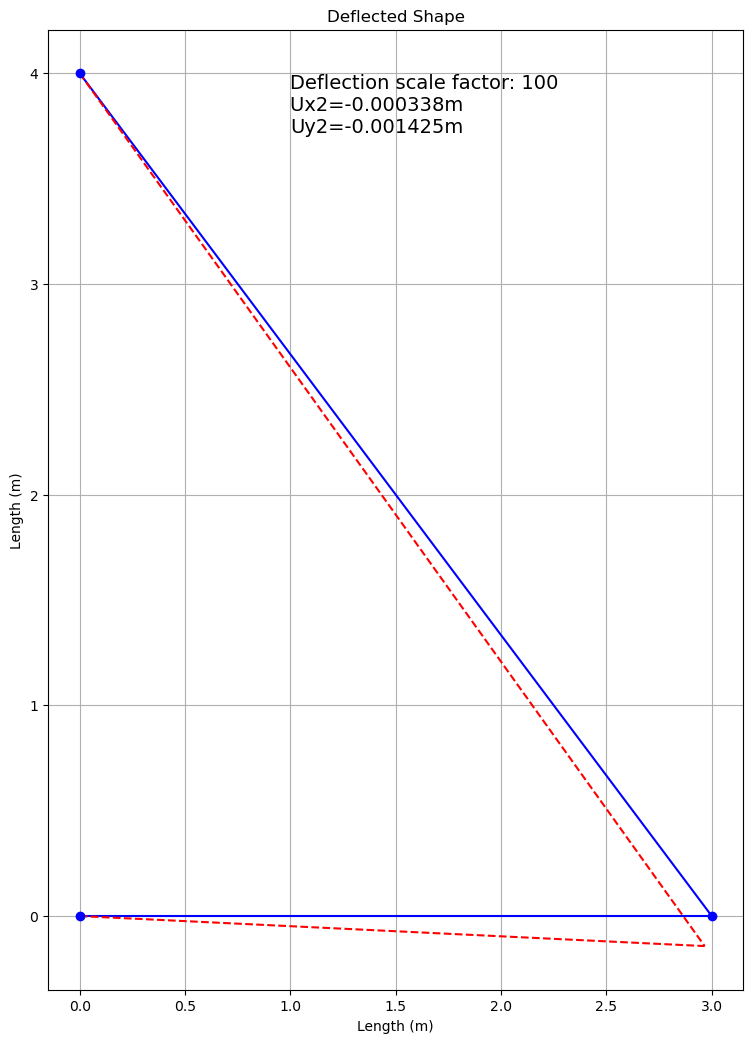

In [75]:
xFact= 100 ## using this to multiply the disp so as to view the very small disp in our figure

label="Deflection scale factor: "+str(xFact)+"\nUx2="+str(round(U_x2,6))+"m \nUy2="+str(round(U_y2,6))+"m"

fig= plt.figure()
axes= fig.add_axes([0,0,2,2])
fig.gca().set_aspect('equal',adjustable='box')

## drawing element B
axes.plot([0,3],[0,0],'b')   ## b=blue line
axes.plot([0,3],[4,0],'b') 

axes.plot([0,3+U_x2*xFact],[0,0+U_y2*xFact],'--r')  ## deformed shape is drawn as a dash line in red
axes.plot([0,3+U_x2*xFact],[4,0+U_y2*xFact],'--r')

axes.plot([0],[0],'bo')    ## blue circle
axes.plot([3],[0],'bo')
axes.plot([0],[4],'bo')

plt.text(1,4, label, fontsize=14,va="top")
axes.grid()
axes.set_title("Deflected Shape")
axes.set_xlabel("Length (m)")
axes.set_ylabel("Length (m)")
plt.show()